In [ ]:
import pandas as pd

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [ ]:
print(pd.unique(fish['Species']))
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_input.head()

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


,Weight,Length,Diagonal,Height,Width
0,242.0,25.4,30.0,11.5200,4.0200
1,290.0,26.3,31.2,12.4800,4.3056
2,340.0,26.5,31.1,12.3778,4.6961
3,363.0,29.0,33.5,12.7300,4.4555
4,430.0,29.0,34.0,12.4440,5.1340


In [ ]:
fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled,train_target)
print(kn.score(train_scaled,train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [ ]:
print(kn.classes_)
print(kn.predict(test_scaled[:5]))

import numpy as np
proba=kn.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=4))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']
[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [ ]:
char_arr=np.array(['A','B','C','D','E'])
print(char_arr[[True,False,True,False,False]])

['A' 'C']


In [ ]:
bream_smelt_indexes=(train_target=='Bream')|(train_target=='Smelt')
train_bream_smelt=train_scaled[bream_smelt_indexes]
target_bream_smelt=train_target[bream_smelt_indexes]

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [ ]:
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [ ]:
print(lr.classes_)

['Bream' 'Smelt']


In [ ]:
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [ ]:
print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [ ]:
proba=lr.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [ ]:
print(lr.coef_.shape,lr.intercept_.shape)

(7, 5) (7,)


In [ ]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

In [ ]:
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

In [ ]:
from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [ ]:
from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [ ]:
sc.partial_fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.7983193277310925
0.775


In [ ]:
import numpy as np
sc=SGDClassifier(loss='log_loss', random_state=42)
train_score=[]
test_score=[]
classes=np.unique(train_target)

In [ ]:
for _ in range(0,300):
    sc.partial_fit(train_scaled,train_target,classes=classes)
    train_score.append(sc.score(train_scaled,train_target))
    test_score.append(sc.score(test_scaled,test_target))

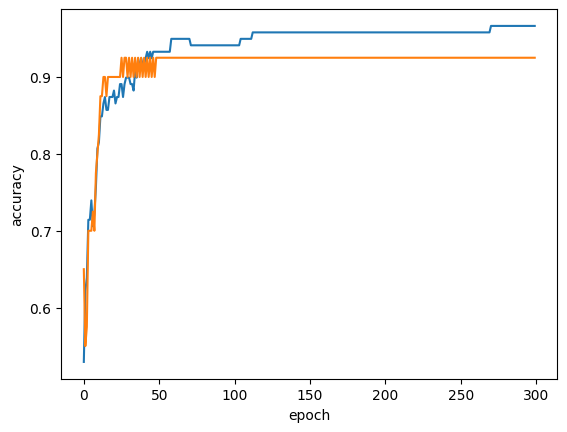

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [ ]:
sc=SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

fish = pd.read_csv('http://bit.ly/fish_csv_data')

fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

train_input, test_input, train_target, test_target = train_test_split(
    fish_input,
    fish_target,
    random_state=42
)

ss = StandardScaler()
ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)

print("훈련 세트 정확도:", lr.score(train_scaled, train_target))
print("테스트 세트 정확도:", lr.score(test_scaled, test_target))

test_data = np.array([
    [350.0, 29.0, 33.5, 10.50, 4.60],
    [18.5, 12.5, 14.0, 2.30, 1.35],
    [820.0, 41.5, 45.0, 7.80, 5.10],
    [160.0, 21.0, 23.5, 6.20, 3.60],
    [550.0, 26.5, 31.0, 13.80, 6.10]
])

test_data_scaled = ss.transform(test_data)

pred = lr.predict(test_data_scaled)
print("새로운 데이터 예측 결과:")
print(pred)

proba = lr.predict_proba(test_data_scaled)

proba_df = pd.DataFrame(
    np.round(proba, 3),
    columns=lr.classes_
)

print("물고기 종류 순서:")
print(lr.classes_)

print("각 데이터별 물고기 분류 확률:")
display(proba_df)

훈련 세트 정확도: 0.9327731092436975
테스트 세트 정확도: 0.925
새로운 데이터 예측 결과:
['Bream' 'Smelt' 'Pike' 'Perch' 'Whitefish']
물고기 종류 순서:
['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
각 데이터별 물고기 분류 확률:


,Bream,Parkki,Perch,Pike,Roach,Smelt,Whitefish
0,0.451,0.049,0.008,0.006,0.384,0.000,0.102
1,0.000,0.002,0.048,0.000,0.009,0.941,0.000
2,0.000,0.000,0.287,0.713,0.000,0.000,0.000
3,0.000,0.013,0.512,0.001,0.461,0.002,0.011
4,0.368,0.094,0.000,0.000,0.009,0.000,0.528


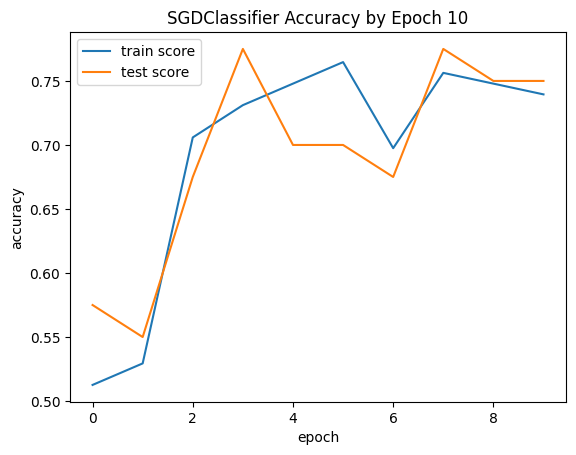

[에포크 10]
훈련 세트 정확도: 0.7394957983193278
테스트 세트 정확도: 0.75


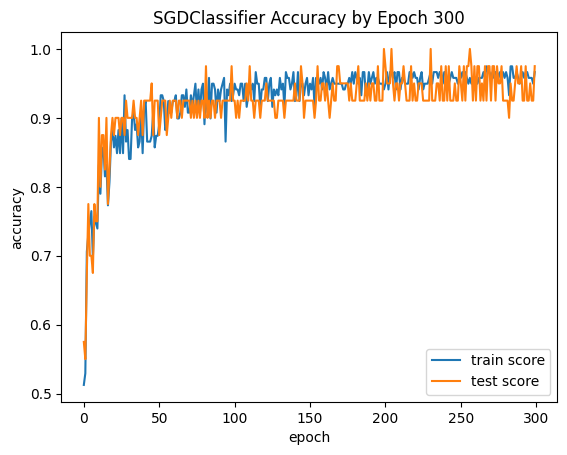


[에포크 300]
훈련 세트 정확도: 0.9663865546218487
테스트 세트 정확도: 0.975

[최적 에포크]
테스트 정확도가 가장 높은 에포크: 200
해당 에포크의 훈련 정확도: 0.9411764705882353
해당 에포크의 테스트 정확도: 1.0

[최적 에포크 모델]
훈련 세트 정확도: 0.9495798319327731
테스트 세트 정확도: 0.925

[에포크 10 모델과 최적 에포크 모델 비교]
에포크 10 테스트 정확도: 0.75
최적 에포크 테스트 정확도: 0.925


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

fish = pd.read_csv('http://bit.ly/fish_csv_data')

fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

train_input, test_input, train_target, test_target = train_test_split(
    fish_input,
    fish_target,
    random_state=42
)

ss = StandardScaler()
ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

classes = np.unique(train_target)

sc_10 = SGDClassifier(loss='hinge', random_state=42)

train_score_10 = []
test_score_10 = []

for epoch in range(10):
    sc_10.partial_fit(train_scaled, train_target, classes=classes)
    train_score_10.append(sc_10.score(train_scaled, train_target))
    test_score_10.append(sc_10.score(test_scaled, test_target))

plt.plot(train_score_10, label='train score')
plt.plot(test_score_10, label='test score')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('SGDClassifier Accuracy by Epoch 10')
plt.show()

print("[에포크 10]")
print("훈련 세트 정확도:", train_score_10[-1])
print("테스트 세트 정확도:", test_score_10[-1])

sc_300 = SGDClassifier(loss='hinge', random_state=42)

train_score_300 = []
test_score_300 = []

for epoch in range(300):
    sc_300.partial_fit(train_scaled, train_target, classes=classes)
    train_score_300.append(sc_300.score(train_scaled, train_target))
    test_score_300.append(sc_300.score(test_scaled, test_target))

plt.plot(train_score_300, label='train score')
plt.plot(test_score_300, label='test score')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('SGDClassifier Accuracy by Epoch 300')
plt.show()

print("\n[에포크 300]")
print("훈련 세트 정확도:", train_score_300[-1])
print("테스트 세트 정확도:", test_score_300[-1])

best_epoch = np.argmax(test_score_300) + 1

print("\n[최적 에포크]")
print("테스트 정확도가 가장 높은 에포크:", best_epoch)
print("해당 에포크의 훈련 정확도:", train_score_300[best_epoch - 1])
print("해당 에포크의 테스트 정확도:", test_score_300[best_epoch - 1])

sc_best = SGDClassifier(
    loss='hinge',
    max_iter=best_epoch,
    tol=None,
    random_state=42
)

sc_best.fit(train_scaled, train_target)

print("\n[최적 에포크 모델]")
print("훈련 세트 정확도:", sc_best.score(train_scaled, train_target))
print("테스트 세트 정확도:", sc_best.score(test_scaled, test_target))

print("\n[에포크 10 모델과 최적 에포크 모델 비교]")
print("에포크 10 테스트 정확도:", test_score_10[-1])
print("최적 에포크 테스트 정확도:", sc_best.score(test_scaled, test_target))